In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, AveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import GlobalMaxPooling2D
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
class CNN:
    def __init__(self, images, labels, input_s = (128, 128, 3)):
        # División de los datos de entrenamiento y prueba
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
        self.input_s = input_s
        # del images, labels  # Liberar memoria

    def CrearModelo(self, nombre):
        self.model = Sequential()

        # Capa Convolucional 1
        self.model.add(Conv2D(32, (3, 3), padding='same', activation = 'relu', kernel_regularizer=l2(0.001), input_shape=self.input_s))
        self.model.add(BatchNormalization())
        self.model.add(MaxPooling2D(pool_size=(2, 2)))

        # Capa Convolucional 2
        self.model.add(Conv2D(64, (3, 3), padding='same', activation = 'relu', kernel_regularizer=l2(0.001)))
        self.model.add(BatchNormalization())
        self.model.add(MaxPooling2D(pool_size=(2, 2)))

        # Capa Convolucional 3
        self.model.add(Conv2D(128, (3, 3), padding='same', activation = 'relu', kernel_regularizer=l2(0.001)))
        self.model.add(BatchNormalization())
        self.model.add(MaxPooling2D(pool_size=(2, 2)))

        # Aplanamiento
        self.model.add(GlobalMaxPooling2D())
        
        # Capas Densa 1
        self.model.add(Dense(128, kernel_regularizer=l2(0.001)))
        self.model.add(LeakyReLU(alpha=0.1))
        self.model.add(Dropout(0.3))

        # Capas Densa 2
        self.model.add(Dense(64, kernel_regularizer=l2(0.001)))
        self.model.add(LeakyReLU(alpha=0.1))
        self.model.add(Dropout(0.3))

        # Capas Densa 3
        self.model.add(Dense(32, kernel_regularizer=l2(0.001)))
        self.model.add(LeakyReLU(alpha=0.1))
        self.model.add(Dropout(0.3)) 

        # Capas Salida
        self.model.add(Dense(8, activation='softmax'))

        # Configuración del guardado del mejor modelo
        self.best_model = ModelCheckpoint(filepath=f'Models/{nombre}.keras', monitor='val_accuracy', save_best_only=True)

        # Compilación del modelo
        self.optimi = Adam(learning_rate=0.0005) # Recomendado para un dataset grande y ruidoso
        self.model.compile(optimizer=self.optimi, loss='categorical_crossentropy', metrics=['accuracy'])

        # Entrenamiento del modelo
        self.history = self.model.fit(self.X_train, self.y_train, epochs=50,
                                    batch_size=32, validation_split=0.1, callbacks=[self.best_model])

        # Carga del mejor modelo después del entrenamiento
        self.model = tf.keras.models.load_model(f'Models/{nombre}.keras')

        return self.model

    def EvaluarModelo(self):
        if self.model is not None:
            # Evaluar loss y accuracy
            self.loss, self.accuracy = self.model.evaluate(self.X_test, self.y_test, verbose=0)
            print(f'Precisión en el conjunto de prueba: {self.accuracy*100:.2f}%')
            
            y_pred_probs = self.model.predict(self.X_test)
            y_pred = np.argmax(y_pred_probs, axis=1)
            y_true = np.argmax(self.y_test, axis=1)
            
            cm = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(10,8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.xlabel('Predicciones')
            plt.ylabel('Clases reales')
            plt.title('Matriz de Confusión')
            plt.show()
            
            print("Reporte de clasificación:\n")
            print(classification_report(y_true, y_pred, digits=4))
            
            return self.accuracy
        else:
            print("El modelo no está cargado.")



In [3]:
y_onehot = np.load("Datos/y_one_hot.npy")

C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 31s 133ms/step - accuracy: 0.1653 - loss: 2.5855 - val_accuracy: 0.1055 - val_loss: 2.6642
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - accuracy: 0.2602 - loss: 2.2868 - val_accuracy: 0.1174 - val_loss: 2.6639
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.3427 - loss: 2.0788 - val_accuracy: 0.3923 - val_loss: 1.9449
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.3946 - loss: 1.9205 - val_accuracy: 0.4993 - val_loss: 1.7722
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 134ms/step - accuracy: 0.4359 - loss: 1.8140 - val_accuracy: 0.4844 - val_loss: 1.7282
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.4465 - loss: 1.7639 - val_accuracy: 0.2972 - val_loss: 2.0960
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.4740 - loss: 1.6988 - val_accuracy: 0.4547 - val_loss: 1.7575
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 150ms/step - accuracy: 0.5209 - loss: 1

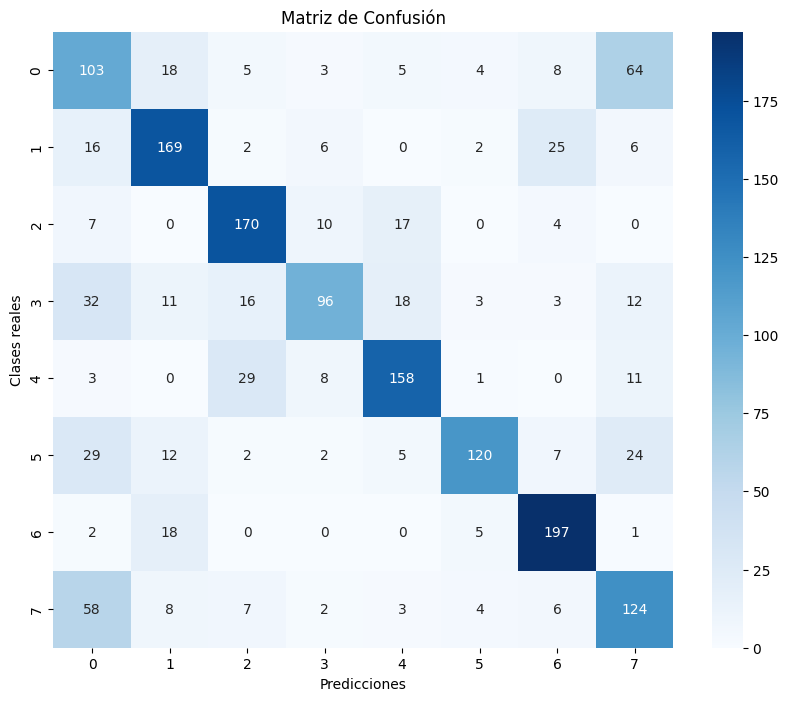

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.4120    0.4905    0.4478       210
           1     0.7161    0.7478    0.7316       226
           2     0.7359    0.8173    0.7745       208
           3     0.7559    0.5026    0.6038       191
           4     0.7670    0.7524    0.7596       210
           5     0.8633    0.5970    0.7059       201
           6     0.7880    0.8834    0.8330       223
           7     0.5124    0.5849    0.5463       212

    accuracy                         0.6764      1681
   macro avg     0.6938    0.6720    0.6753      1681
weighted avg     0.6929    0.6764    0.6774      1681



0.6763830780982971

In [4]:
X_rgb_64 = np.load("Datos/X_rgb_64.npy")
redConvolucional_rgb = CNN(X_rgb_64, y_onehot, (64, 64, 3))
del X_rgb_64
redConvolucional_rgb.CrearModelo('X_rgb_64')
redConvolucional_rgb.EvaluarModelo()

C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 111s 548ms/step - accuracy: 0.2047 - loss: 2.6159 - val_accuracy: 0.1025 - val_loss: 2.6888
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 103s 543ms/step - accuracy: 0.2949 - loss: 2.1477 - val_accuracy: 0.1233 - val_loss: 2.4783
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 103s 542ms/step - accuracy: 0.3799 - loss: 1.9724 - val_accuracy: 0.3952 - val_loss: 1.9313
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 108s 570ms/step - accuracy: 0.4168 - loss: 1.8563 - val_accuracy: 0.4695 - val_loss: 1.7002
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 105s 550ms/step - accuracy: 0.4490 - loss: 1.7733 - val_accuracy: 0.4681 - val_loss: 1.7624
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 103s 540ms/step - accuracy: 0.4773 - loss: 1.7162 - val_accuracy: 0.4101 - val_loss: 1.7779
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 103s 542ms/step - accuracy: 0.4759 - loss: 1.7260 - val_accuracy: 0.4116 - val_loss: 1.8937
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 102s 536ms/step - accuracy: 0.5288 -

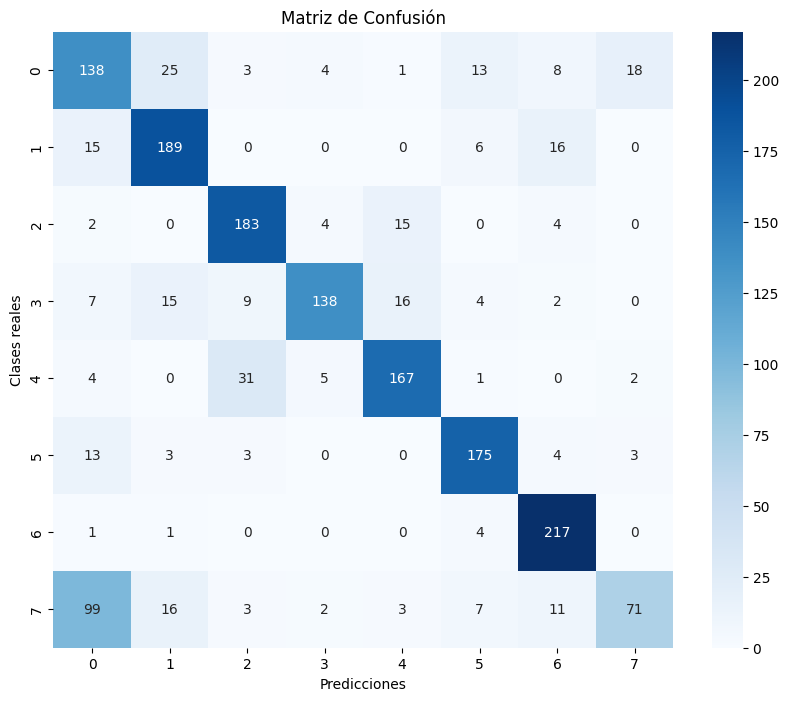

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.4946    0.6571    0.5644       210
           1     0.7590    0.8363    0.7958       226
           2     0.7888    0.8798    0.8318       208
           3     0.9020    0.7225    0.8023       191
           4     0.8267    0.7952    0.8107       210
           5     0.8333    0.8706    0.8516       201
           6     0.8282    0.9731    0.8948       223
           7     0.7553    0.3349    0.4641       212

    accuracy                         0.7603      1681
   macro avg     0.7735    0.7587    0.7519      1681
weighted avg     0.7720    0.7603    0.7519      1681



0.7602617740631104

In [5]:
X_rgb_128 = np.load("Datos/X_rgb_128.npy")
redConvolucional_rgb = CNN(X_rgb_128, y_onehot, (128, 128, 3))
del X_rgb_128
redConvolucional_rgb.CrearModelo('X_rgb_128')
redConvolucional_rgb.EvaluarModelo()

C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.1871 - loss: 2.5277 - val_accuracy: 0.1218 - val_loss: 2.7094
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.3050 - loss: 2.1492 - val_accuracy: 0.1738 - val_loss: 2.5758
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 27s 139ms/step - accuracy: 0.3546 - loss: 2.0439 - val_accuracy: 0.4071 - val_loss: 1.9397
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.4097 - loss: 1.9019 - val_accuracy: 0.3848 - val_loss: 1.9531
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step - accuracy: 0.4511 - loss: 1.7708 - val_accuracy: 0.4606 - val_loss: 1.7505
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.4883 - loss: 1.6851 - val_accuracy: 0.5498 - val_loss: 1.5990
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 26s 134ms/step - accuracy: 0.5252 - loss: 1.5946 - val_accuracy: 0.5186 - val_loss: 1.6045
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 25s 134ms/step - accuracy: 0.5485 - loss: 1

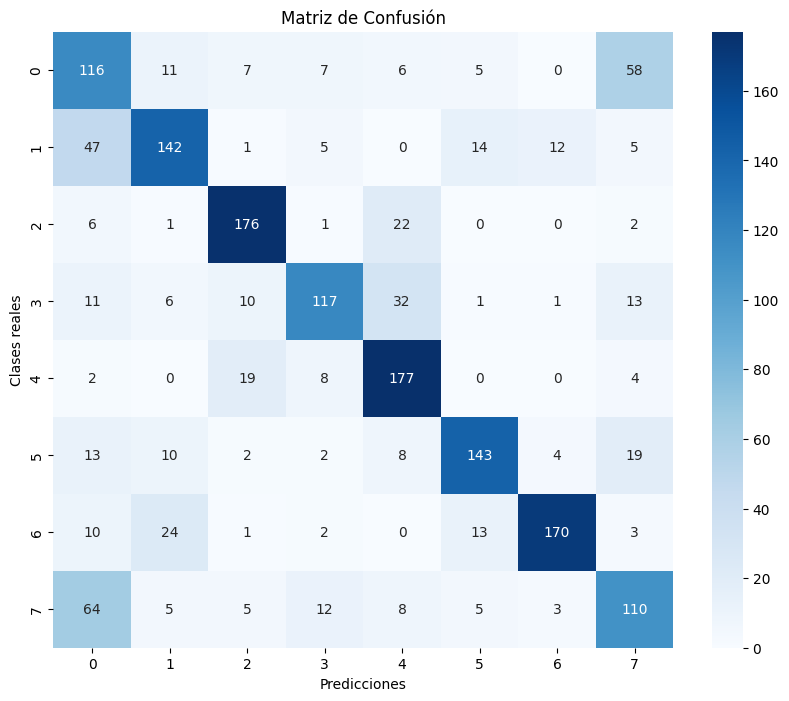

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.4312    0.5524    0.4843       210
           1     0.7136    0.6283    0.6682       226
           2     0.7964    0.8462    0.8205       208
           3     0.7597    0.6126    0.6783       191
           4     0.6996    0.8429    0.7646       210
           5     0.7901    0.7114    0.7487       201
           6     0.8947    0.7623    0.8232       223
           7     0.5140    0.5189    0.5164       212

    accuracy                         0.6847      1681
   macro avg     0.6999    0.6844    0.6880      1681
weighted avg     0.7001    0.6847    0.6883      1681



0.6847114562988281

In [6]:
X_hsv_64 = np.load("Datos/X_hsv_64.npy")
redConvolucional_hsv = CNN(X_hsv_64, y_onehot, (64, 64, 3))
del X_hsv_64
redConvolucional_hsv.CrearModelo('X_hsv_64')
redConvolucional_hsv.EvaluarModelo()

C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\abiab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 114s 565ms/step - accuracy: 0.1936 - loss: 2.5148 - val_accuracy: 0.1055 - val_loss: 2.5799
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 105s 550ms/step - accuracy: 0.3381 - loss: 2.1107 - val_accuracy: 0.1248 - val_loss: 2.6408
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 99s 521ms/step - accuracy: 0.3958 - loss: 1.9429 - val_accuracy: 0.3893 - val_loss: 1.9735
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 99s 522ms/step - accuracy: 0.4217 - loss: 1.8435 - val_accuracy: 0.4502 - val_loss: 1.7650
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 100s 525ms/step - accuracy: 0.4784 - loss: 1.7169 - val_accuracy: 0.5245 - val_loss: 1.6269
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 99s 521ms/step - accuracy: 0.4943 - loss: 1.6833 - val_accuracy: 0.5483 - val_loss: 1.5403
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 99s 521ms/step - accuracy: 0.5346 - loss: 1.5751 - val_accuracy: 0.5810 - val_loss: 1.5237
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 99s 521ms/step - accuracy: 0.5571 - loss

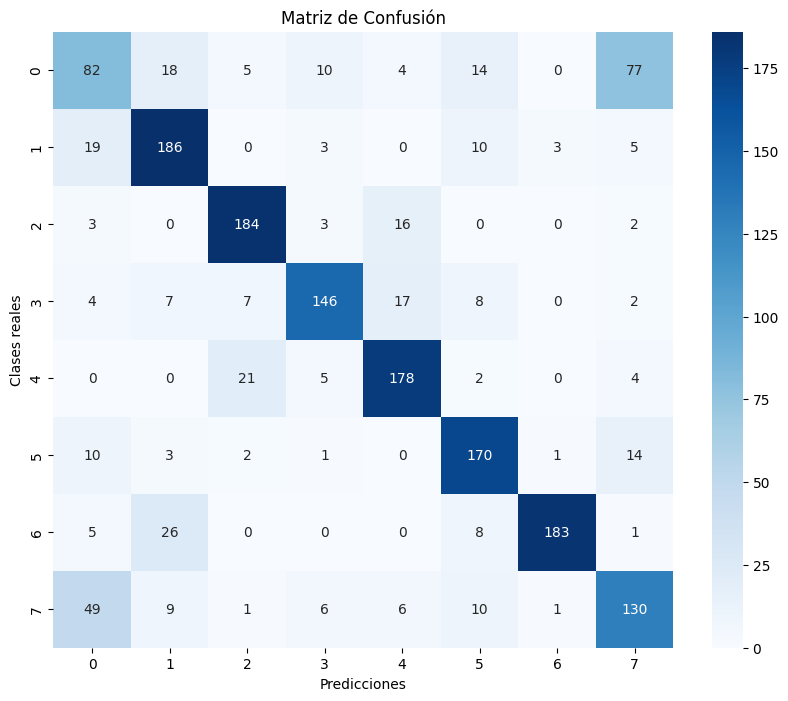

Reporte de clasificación:

              precision    recall  f1-score   support

           0     0.4767    0.3905    0.4293       210
           1     0.7470    0.8230    0.7832       226
           2     0.8364    0.8846    0.8598       208
           3     0.8391    0.7644    0.8000       191
           4     0.8054    0.8476    0.8260       210
           5     0.7658    0.8458    0.8038       201
           6     0.9734    0.8206    0.8905       223
           7     0.5532    0.6132    0.5817       212

    accuracy                         0.7490      1681
   macro avg     0.7496    0.7487    0.7468      1681
weighted avg     0.7499    0.7490    0.7470      1681



0.748958945274353

In [7]:
X_hsv_128 = np.load("Datos/X_hsv_128.npy")
redConvolucional_hsv = CNN(X_hsv_128, y_onehot, (128, 128, 3))
del X_hsv_128
redConvolucional_hsv.CrearModelo('X_hsv_128')
redConvolucional_hsv.EvaluarModelo()